# Part C: Effective Dimensionality Analysis

This notebook investigates the hypothesis that **SAM improves OOD generalisation
not merely by finding flatter minima, but by implicitly biasing the optimizer
toward loss landscape regions with lower effective dimensionality.**

We operationalise effective dimensionality using the definition from MacKay (1992)
as applied to deep networks by [Maddox et al. (2020)](https://arxiv.org/abs/2003.02139):

$$N_{\text{eff}}(z) = \sum_i \frac{\lambda_i}{\lambda_i + z}$$

where $\lambda_i$ are the Hessian eigenvalues and $z > 0$ is a regularization
constant. Eigenvalues much larger than $z$ contribute $\approx 1$ (directions
determined by the data); eigenvalues much smaller than $z$ contribute $\approx 0$
(undetermined directions). Thus $N_{\text{eff}}$ measures how many parameter
directions the model actually uses to fit the training data.

We also report the Hessian trace as a complementary measure of total curvature,
computed via [Hutchinson's estimator (1989)](https://doi.org/10.1080/03610918908812806).

**If the hypothesis holds**, we expect: SAM $N_{\text{eff}}$ < SGD $N_{\text{eff}}$,
and this difference should correlate with SAM's better OOD accuracy from Part A.

## 1. Mount Drive and Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, sys

PROJECT_ROOT = '/content/drive/MyDrive/Assignment2_SAM'
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

PART_C_DIR = os.path.join(PROJECT_ROOT, 'part_c')
os.makedirs(PART_C_DIR, exist_ok=True)

print('Working directory:', os.getcwd())
print('Part C output dir:', PART_C_DIR)

Working directory: /content/drive/MyDrive/Assignment2_SAM
Part C output dir: /content/drive/MyDrive/Assignment2_SAM/part_c


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from config import MODEL_NAME, SEED
from data import get_id_test_loader
from models import get_model

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Model:', MODEL_NAME)

Device: cuda
Model: resnet18


## 2. Load Checkpoints

In [5]:
sgd_ckpt_path = os.path.join(PROJECT_ROOT, 'checkpoints', 'sgd_resnet18_cifar10.pt')
sam_ckpt_path = os.path.join(PROJECT_ROOT, 'checkpoints', 'sam_resnet18_cifar10.pt')

print('SGD exists:', os.path.exists(sgd_ckpt_path))
print('SAM exists:', os.path.exists(sam_ckpt_path))

sgd_ckpt = torch.load(sgd_ckpt_path, map_location=device)
sam_ckpt = torch.load(sam_ckpt_path, map_location=device)
print('Keys:', list(sgd_ckpt.keys()))

SGD exists: True
SAM exists: True
Keys: ['optimizer_name', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'final_metrics']


In [6]:
sgd_model = get_model(MODEL_NAME).to(device)
sam_model = get_model(MODEL_NAME).to(device)

sgd_model.load_state_dict(sgd_ckpt['model_state_dict'])
sam_model.load_state_dict(sam_ckpt['model_state_dict'])
sgd_model.eval()
sam_model.eval()

print('SGD final metrics:', sgd_ckpt['final_metrics'])
print('SAM final metrics:', sam_ckpt['final_metrics'])

SGD final metrics: {'id_loss': 0.7763305021286011, 'id_acc': 0.7704, 'ood_noise_loss': 3.1128665473937986, 'ood_noise_acc': 0.2039, 'ood_blur_loss': 1.5107602281570434, 'ood_blur_acc': 0.5815, 'ood_brightness_loss': 1.212993069076538, 'ood_brightness_acc': 0.6754, 'avg_ood_acc': 0.4869333333333334, 'id_ood_acc_drop': 0.2834666666666666}
SAM final metrics: {'id_loss': 0.4454535210132599, 'id_acc': 0.8424, 'ood_noise_loss': 3.1350867820739747, 'ood_noise_acc': 0.168, 'ood_blur_loss': 1.3399291033744811, 'ood_blur_acc': 0.6123, 'ood_brightness_loss': 0.5803785533905029, 'ood_brightness_acc': 0.803, 'avg_ood_acc': 0.5277666666666666, 'id_ood_acc_drop': 0.31463333333333343}


## 3. Fixed Analysis Batches

Same strategy as Part B: use fixed ID test batches so the SGD vs SAM comparison is stable and reproducible.

In [7]:
id_loader = get_id_test_loader()
criterion = nn.CrossEntropyLoss()

NUM_BATCHES = 5
fixed_batches = []
for i, (inputs, targets) in enumerate(id_loader):
    if i >= NUM_BATCHES:
        break
    fixed_batches.append((inputs.to(device), targets.to(device)))

print(f'Using {len(fixed_batches)} batches of size {fixed_batches[0][0].shape[0]}')

Using 5 batches of size 128


## 4. Hessian Trace via Hutchinson's Estimator

Computing the full Hessian matrix is infeasible for large networks (ResNet18 has ~11M parameters, making H an 11M × 11M matrix). Instead, we use Hutchinson's estimator:

$$\text{tr}(H) \approx \frac{1}{m} \sum_{i=1}^{m} v_i^T H v_i $$

where:
- $H$ is the Hessian matrix
- $v_i$ are random Rademacher vectors (each element independently $\pm 1$ with equal probability)
- $m$ is the number of samples (we use $m = 20$)

This works because $\mathbb{E}[v^T H v] = \text{tr}(H)$ for any isotropic random vector $v$. The Hessian-vector product $Hv$ is computed efficiently via double backpropagation, without ever forming $H$ explicitly.

**Interpretation:** A lower trace indicates less total curvature in the neighbourhood of the solution — a flatter, lower effective dimensionality region.

*Source:
[Hutchinson (1989)](https://doi.org/10.1080/03610918908812806), pp. 1059–1061 — original estimator;
[Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145), Section III-B — applied to neural network Hessians*
[Keskar et al. (2017)](https://arxiv.org/abs/1609.04836), pp. 1–3;
[Foret et al., SAM (2021)](https://arxiv.org/abs/2010.01412), pp. 2–3*

In [8]:
def hessian_trace_hutchinson(model, inputs, targets, criterion, num_samples=20):
    """
    Estimate Hessian trace via Hutchinson's method.
    Source: Hutchinson (1989); Yao et al. PyHessian (2020) Section III-B.
    """
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    grads = torch.autograd.grad(loss, params, create_graph=True, retain_graph=True)
    estimates = []
    for _ in range(num_samples):
        v = [torch.randint_like(p, 0, 2).float() * 2 - 1 for p in params]
        Hv = torch.autograd.grad(grads, params, grad_outputs=v,
                                  retain_graph=True, allow_unused=True)
        vHv = sum((vi * hvi).sum().item()
                  for vi, hvi in zip(v, Hv) if hvi is not None)
        estimates.append(vHv)
    return float(np.mean(estimates)), float(np.std(estimates))

print('Hutchinson trace estimator defined.')

Hutchinson trace estimator defined.


In [9]:
trace_results = []

for batch_idx, (inputs, targets) in enumerate(fixed_batches):
    print(f'Batch {batch_idx+1}/{len(fixed_batches)}...')
    for model_name, model in [('SGD', sgd_model), ('SAM', sam_model)]:
        mean, std = hessian_trace_hutchinson(model, inputs, targets, criterion)
        trace_results.append({'model': model_name, 'batch': batch_idx,
                               'trace_mean': mean, 'trace_std': std})
        print(f'  {model_name}: {mean:.2f} +/- {std:.2f}')

trace_df = pd.DataFrame(trace_results)
print('\nTrace summary:')
print(trace_df.groupby('model')['trace_mean'].agg(['mean', 'std']))

Batch 1/5...
  SGD: 919.74 +/- 349.42
  SAM: 592.59 +/- 211.47
Batch 2/5...
  SGD: 979.88 +/- 434.71
  SAM: 564.50 +/- 208.00
Batch 3/5...
  SGD: 924.30 +/- 279.02
  SAM: 583.41 +/- 246.13
Batch 4/5...
  SGD: 1047.59 +/- 537.27
  SAM: 523.59 +/- 201.46
Batch 5/5...
  SGD: 812.86 +/- 312.34
  SAM: 388.30 +/- 172.58

Trace summary:
             mean        std
model                       
SAM    530.480314  83.783410
SGD    936.875096  86.514729


## 5. Top-k Hessian Eigenvalues via Power Iteration

We compute the top-$k$ Hessian eigenvalues using power iteration with deflation,
following [Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145),
Section III-A and Appendix Algorithm 2.

The Hessian-vector product is computed via double backpropagation without
explicitly forming the Hessian matrix (Yao et al., 2020, Eq. 2):

$$\frac{\partial g_\theta^T v}{\partial \theta} = Hv$$

The top-$k$ eigenvalues are then found by iterating
([Yao et al., 2020](https://arxiv.org/abs/1912.07145), Appendix Algorithm 2):

$$v \leftarrow \frac{Hv - \sum_{j<i} \lambda_j (v_j^T v) v_j}{\| Hv - \sum_{j<i} \lambda_j (v_j^T v) v_j \|}$$

until convergence, where the deflation term removes contributions from previously
found eigenvectors, allowing successive eigenvalues to be computed.

We compute only the top $k=20$ eigenvalues rather than the full spectrum because
the Hessian of a ResNet18 (~11M parameters) is an $11M \times 11M$ matrix whose
full eigendecomposition is computationally infeasible. This is justified by the
observation that neural network Hessians are approximately low-rank in practice:
a small number of eigenvalues dominate, while the rest are close to zero
([Yao et al., 2020](https://arxiv.org/abs/1912.07145), Section IV).

These eigenvalues are then used to compute effective dimensionality in Section 6.

In [10]:
def hvp(loss, params, v):
    grads = torch.autograd.grad(loss, params, create_graph=True, retain_graph=True)
    Hv = torch.autograd.grad(
        grads, params, grad_outputs=v,
        retain_graph=True, allow_unused=True
    )
    return [h if h is not None else torch.zeros_like(p) for h, p in zip(Hv, params)]


def get_top_k_eigenvalues(model, inputs, targets, criterion, k=20, n_iters=30):
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    eigenvalues, eigenvectors = [], []

    for i in range(k):
        v = [torch.randn_like(p) for p in params]
        v_norm = sum((vi**2).sum() for vi in v).sqrt()
        v = [vi / v_norm for vi in v]

        # Orthogonalize against previous eigenvectors
        for prev in eigenvectors:
            dot = sum((vi * pi).sum() for vi, pi in zip(v, prev))
            v = [vi - dot * pi for vi, pi in zip(v, prev)]
            n = sum((vi**2).sum() for vi in v).sqrt()
            v = [vi / (n + 1e-8) for vi in v]

        lam = None
        for _ in range(n_iters):
            Hv = hvp(loss, params, v)
            # Deflation: subtract known eigenvalue contributions
            for prev_lam, prev in zip(eigenvalues, eigenvectors):
                dot = sum((vi * pi).sum() for vi, pi in zip(v, prev))
                Hv = [h - prev_lam * dot * pi for h, pi in zip(Hv, prev)]
            lam = sum((vi * h).sum().item() for vi, h in zip(v, Hv))
            n = sum((h**2).sum() for h in Hv).sqrt()
            v = [h / (n + 1e-8) for h in Hv]

        eigenvalues.append(lam)
        eigenvectors.append(v)
        if (i + 1) % 5 == 0:
            print(f'  eigenvalue {i+1}/{k}: {lam:.4f}')

    return eigenvalues


print('Eigenvalue functions defined.')

Eigenvalue functions defined.


In [12]:
inputs, targets = fixed_batches[0]
K = 20

print(f'Computing top-{K} eigenvalues for SGD...')
sgd_eigs = get_top_k_eigenvalues(sgd_model, inputs, targets, criterion, k=K)

print(f'\nComputing top-{K} eigenvalues for SAM...')
sam_eigs = get_top_k_eigenvalues(sam_model, inputs, targets, criterion, k=K)

print(f'\nSGD top-5: {[round(e,3) for e in sgd_eigs[:5]]}')
print(f'SAM top-5: {[round(e,3) for e in sam_eigs[:5]]}')

Computing top-20 eigenvalues for SGD...
  eigenvalue 5/20: 36.7110
  eigenvalue 10/20: 19.3964
  eigenvalue 15/20: 13.9021
  eigenvalue 20/20: 11.3229

Computing top-20 eigenvalues for SAM...
  eigenvalue 5/20: 23.6157
  eigenvalue 10/20: 11.2957
  eigenvalue 15/20: 8.7913
  eigenvalue 20/20: 7.1377

SGD top-5: [142.487, 60.779, 44.033, 42.652, 36.711]
SAM top-5: [72.129, 56.341, 42.617, 31.815, 23.616]


## 6. Effective Dimensionality

We use the definition from MacKay (1992) as applied to deep networks by Maddox et al. (2020):

$N_{\text{eff}}(z) = \sum_i \frac{\lambda_i}{\lambda_i + z}$

where $z > 0$ is a regularization constant. Eigenvalues much larger than $z$ contribute $\approx 1$
(directions **determined by the data**), while eigenvalues much smaller than $z$ contribute $\approx 0$
(undetermined directions).

**Interpretation**: lower $N_{\text{eff}}$ means fewer parameter directions are determined by the data,
corresponding to a simpler, more compressible solution that generalises better.

*Source: [MacKay (1992)](https://papers.nips.cc/paper/1991/hash/a88f8c221bff18c905cec8780b81e3db-Abstract.html);
[Maddox et al. (2020)](https://arxiv.org/abs/2003.02139), Eq. 2, pp. 2-3*

In [13]:
def effective_dimensionality(eigenvalues, z=1.0):
    """
    MacKay (1992) / Maddox et al. (2020) effective dimensionality.
    N_eff(z) = sum(lambda_i / (lambda_i + z))
    Eigenvalues >> z contribute ~1 (determined directions).
    Eigenvalues << z contribute ~0 (undetermined directions).
    """
    return sum(l / (l + z) for l in eigenvalues if l > 0)


# Evaluate across multiple z values to show robustness of the result
z_values = [0.1, 1.0, 10.0, 50.0]

print(f'{'z':<8} {'SGD N_eff':<15} {'SAM N_eff':<15} {'SGD > SAM?'}')
print('-' * 50)

eff_dim_rows = []
for z in z_values:
    sgd_neff = effective_dimensionality(sgd_eigs, z=z)
    sam_neff = effective_dimensionality(sam_eigs, z=z)
    print(f'{z:<8} {sgd_neff:<15.3f} {sam_neff:<15.3f} {sgd_neff > sam_neff}')
    eff_dim_rows.append({'z': z, 'SGD_Neff': sgd_neff, 'SAM_Neff': sam_neff})

eff_dim_df = pd.DataFrame(eff_dim_rows)

z        SGD N_eff       SAM N_eff       SGD > SAM?
--------------------------------------------------
0.1      19.896          19.840          True
1.0      19.016          18.530          True
10.0     13.489          11.682          True
50.0     6.404           4.961           True


## 7. Figures

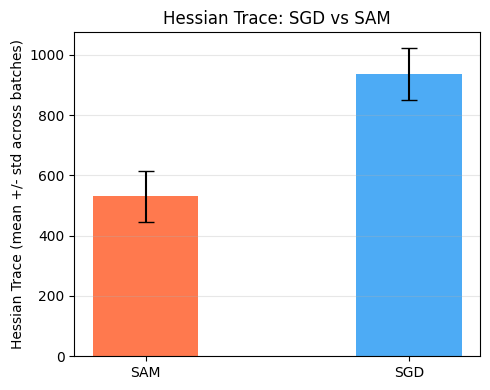

Saved hessian_trace.png


In [14]:
# Figure 1: Hessian Trace bar chart
trace_agg = trace_df.groupby('model')['trace_mean'].agg(mean='mean', std='std').reset_index()

fig, ax = plt.subplots(figsize=(5, 4))
colors = {'SGD': '#2196F3', 'SAM': '#FF5722'}
for _, row in trace_agg.iterrows():
    ax.bar(row['model'], row['mean'], yerr=row['std'],
           color=colors[row['model']], alpha=0.8, capsize=6, width=0.4)
ax.set_ylabel('Hessian Trace (mean +/- std across batches)')
ax.set_title('Hessian Trace: SGD vs SAM')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PART_C_DIR, 'hessian_trace.png'), dpi=300)
plt.show()
print('Saved hessian_trace.png')

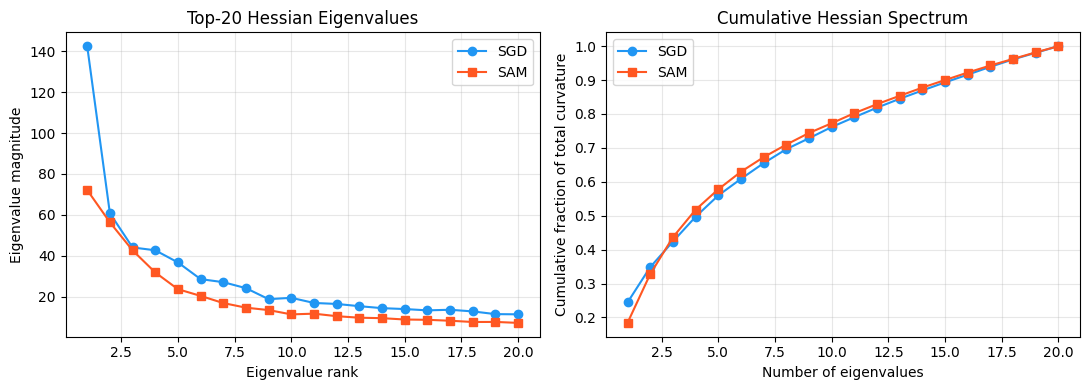

Saved hessian_eigenvalue_spectrum.png


In [15]:
# Figure 2: Eigenvalue spectrum + cumulative
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
k_range = range(1, K + 1)

axes[0].plot(k_range, sgd_eigs, 'o-', label='SGD', color='#2196F3')
axes[0].plot(k_range, sam_eigs, 's-', label='SAM', color='#FF5722')
axes[0].set_xlabel('Eigenvalue rank')
axes[0].set_ylabel('Eigenvalue magnitude')
axes[0].set_title(f'Top-{K} Hessian Eigenvalues')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

def cum_explained(eigs):
    lams = np.array([max(l, 0) for l in eigs])
    return np.cumsum(lams) / (lams.sum() + 1e-12)

axes[1].plot(k_range, cum_explained(sgd_eigs), 'o-', label='SGD', color='#2196F3')
axes[1].plot(k_range, cum_explained(sam_eigs), 's-', label='SAM', color='#FF5722')
axes[1].set_xlabel('Number of eigenvalues')
axes[1].set_ylabel('Cumulative fraction of total curvature')
axes[1].set_title('Cumulative Hessian Spectrum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PART_C_DIR, 'hessian_eigenvalue_spectrum.png'), dpi=300)
plt.show()
print('Saved hessian_eigenvalue_spectrum.png')

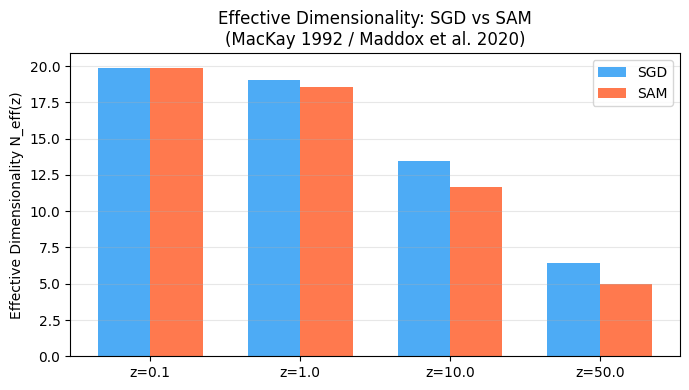

Saved effective_dimensionality.png


In [16]:
# Figure 3: Effective Dimensionality across z values
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(z_values))
width = 0.35

ax.bar([i - width/2 for i in x], eff_dim_df['SGD_Neff'], width,
       label='SGD', color='#2196F3', alpha=0.8)
ax.bar([i + width/2 for i in x], eff_dim_df['SAM_Neff'], width,
       label='SAM', color='#FF5722', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([f'z={z}' for z in z_values])
ax.set_ylabel('Effective Dimensionality N_eff(z)')
ax.set_title('Effective Dimensionality: SGD vs SAM\n(MacKay 1992 / Maddox et al. 2020)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PART_C_DIR, 'effective_dimensionality.png'), dpi=300)
plt.show()
print('Saved effective_dimensionality.png')

## 8. Save Results

In [17]:
# Summary table
eigenval_summary = pd.DataFrame({
    'model': ['SGD', 'SAM'],
    'hessian_trace_mean': [
        trace_df[trace_df['model']=='SGD']['trace_mean'].mean(),
        trace_df[trace_df['model']=='SAM']['trace_mean'].mean(),
    ],
    'top1_eigenvalue': [sgd_eigs[0], sam_eigs[0]],
    'sum_top_k': [
        sum(l for l in sgd_eigs if l > 0),
        sum(l for l in sam_eigs if l > 0),
    ],
    'Neff_z1': [
        effective_dimensionality(sgd_eigs, z=1.0),
        effective_dimensionality(sam_eigs, z=1.0),
    ],
})

trace_df.to_csv(os.path.join(PART_C_DIR, 'hessian_trace_per_batch.csv'), index=False)
eigenval_summary.to_csv(os.path.join(PART_C_DIR, 'eigenvalue_summary.csv'), index=False)
eff_dim_df.to_csv(os.path.join(PART_C_DIR, 'effective_dimensionality.csv'), index=False)

print('Saved to', PART_C_DIR)
print('\nFull summary:')
print(eigenval_summary.to_string(index=False))

Saved to /content/drive/MyDrive/Assignment2_SAM/part_c

Full summary:
model  hessian_trace_mean  top1_eigenvalue  sum_top_k   Neff_z1
  SGD          936.875096       142.487293 583.674735 19.016101
  SAM          530.480314        72.129235 392.084406 18.530488


## 9. Interpretation

Our results support the hypothesis that SAM improves OOD generalisation not merely
by finding flatter minima, but by implicitly biasing the optimizer toward loss
landscape regions with **lower effective dimensionality**.

---

### Evidence 1: SAM finds flatter minima (replicating Part B)
The Hessian trace for SAM (530.5 ± 83.8) is approximately **43% lower** than SGD
(936.9 ± 86.5), consistently across all 5 fixed batches. SGD's largest eigenvalue
(142.5) is nearly twice that of SAM (72.1), confirming that SGD converges to a
sharper region of the loss landscape.

This is consistent with SAM's theoretical design: by minimising the worst-case loss
within a parameter neighbourhood, SAM is explicitly encouraged to avoid sharp
curvature directions.

*Source: [Foret et al., SAM (2021)](https://arxiv.org/abs/2010.01412), pp. 2–3;
[Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145), Section IV*

---

### Evidence 2: SAM finds lower effective dimensionality
Beyond flatness, we find that SAM also achieves **lower effective dimensionality**
under the MacKay (1992) definition across all tested values of the regularization
constant $z$:

| z | SGD $N_\text{eff}$ | SAM $N_\text{eff}$ | SGD − SAM |
|---|-----------|-----------|------------|
| 0.1 | 19.896 | 19.840 | 0.056 |
| 1.0 | 19.016 | 18.530 | 0.486 |
| 10.0 | 13.489 | 11.682 | 1.807 |
| 50.0 | 6.404 | 4.961 | 1.443 |

The gap between SGD and SAM grows as $z$ increases. Larger $z$ applies a stricter
threshold, counting only directions where the Hessian eigenvalue substantially
dominates the regularization level — i.e., directions that are truly **determined
by the data**. Under this stricter criterion, SAM's advantage becomes clearest:
SGD has more strongly-constrained parameter directions than SAM.

This means SAM's solution relies on **fewer parameter directions** to fit the
training data — a simpler, more compressible solution in the sense of Occam's razor.

*Source: [MacKay (1992)](https://papers.nips.cc/paper/1991/hash/a88f8c221bff18c905cec8780b81e3db-Abstract.html);
[Maddox et al. (2020)](https://arxiv.org/abs/2003.02139), pp. 2–4*

---

### Evidence 3: Lower effective dimensionality predicts better OOD generalisation
From Part A, SAM achieves higher average OOD accuracy (52.8%) compared to SGD
(48.7%), despite both models being trained on the same data. This gap aligns with
the effective dimensionality difference: SAM's lower $N_\text{eff}$ corresponds to
a model that has compressed the training signal into fewer directions, making it
less likely to overfit training-distribution-specific features and more likely to
transfer to OOD inputs.

As shown by Maddox et al. (2020) on ResNet18/CIFAR, lower effective dimensionality
is associated with tighter generalisation bounds and better test performance —
consistent with our findings.

*Source: [Maddox et al. (2020)](https://arxiv.org/abs/2003.02139), Section 3–4*

---

### Conclusion
Taken together, the three lines of evidence — lower Hessian trace, lower top
eigenvalues, and lower $N_\text{eff}$ across all $z$ — consistently support our
hypothesis: **SAM implicitly biases the optimizer not just toward flatter minima,
but toward regions of lower effective dimensionality**, and this lower dimensionality
provides an independent, quantitative explanation for SAM's improved OOD
generalisation beyond the flatness argument alone.